# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Elga Emiliana Putri
- **Email:** emilianaaelgaa@gmail.com
- **ID Dicoding:** CDCC200D6X1936

## Menentukan Pertanyaan Bisnis

Berdasarkan E-Commerce Public Dataset, proyek ini bertujuan untuk menganalisis performa penjualan, kontribusi kategori produk, dan segmentasi pelanggan berdasarkan perilaku pembelian. Pertanyaan bisnis disusun menggunakan prinsip pertanyaan analisis yang efektif, yaitu specific, measurable, action-oriented, relevant, dan time-bound.

Pertanyaan bisnis yang akan dijawab dalam proyek ini adalah sebagai berikut:

1. Bagaimana tren jumlah pesanan dan total pendapatan bulanan dari pesanan berstatus delivered selama periode 2016–2018?

2. Kategori produk apa yang menghasilkan total pendapatan tertinggi dan terendah dari pesanan berstatus delivered selama periode 2016–2018?

3. Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary dari pesanan berstatus delivered, serta segmen pelanggan mana yang perlu diprioritaskan untuk strategi retensi?

Pertanyaan pertama digunakan untuk memahami pola performa penjualan dari waktu ke waktu. Pertanyaan kedua digunakan untuk mengetahui kategori produk yang memberikan kontribusi pendapatan terbesar dan terkecil. Pertanyaan ketiga digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian sehingga perusahaan dapat menentukan strategi retensi pelanggan yang lebih tepat.

## Import Semua Packages/Library yang Digunakan

Pada tahap ini, dilakukan import library yang dibutuhkan untuk proses analisis data, mulai dari pengolahan data, visualisasi data, hingga pengolahan tanggal. Library yang digunakan antara lain pandas, numpy, matplotlib, seaborn, dan datetime.

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [188]:
# Mengekstrak file ZIP dataset ke folder data
import zipfile
import os

zip_path = "E-commerce-public-dataset.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Mengecek isi folder data
for root, dirs, files in os.walk("data"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

data/E-Commerce Public Dataset/sellers_dataset.csv
data/E-Commerce Public Dataset/orders_dataset.csv
data/E-Commerce Public Dataset/order_payments_dataset.csv
data/E-Commerce Public Dataset/product_category_name_translation.csv
data/E-Commerce Public Dataset/customers_dataset.csv
data/E-Commerce Public Dataset/order_items_dataset.csv
data/E-Commerce Public Dataset/order_reviews_dataset.csv
data/E-Commerce Public Dataset/geolocation_dataset.csv
data/E-Commerce Public Dataset/products_dataset.csv


## Data Wrangling

Pada tahap data wrangling, data disiapkan terlebih dahulu sebelum masuk ke proses analisis. Tahapan ini terdiri dari gathering data, assessing data, dan cleaning data. Tujuannya adalah memastikan data yang digunakan sudah terbaca dengan baik, dipahami strukturnya, serta dibersihkan dari masalah yang dapat memengaruhi hasil analisis.

### Gathering Data

Pada tahap ini, memuat seluruh file dataset yang akan digunakan dalam analisis. Dataset E-Commerce Public Dataset terdiri dari beberapa file yang saling berkaitan, seperti data pelanggan, pesanan, item pesanan, pembayaran, ulasan, produk, penjual, geolokasi, dan terjemahan kategori produk.


In [189]:
# Memuat seluruh dataset ke dalam dataframe
customers_df = pd.read_csv("data/E-Commerce Public Dataset/customers_dataset.csv")
geolocation_df = pd.read_csv("data/E-Commerce Public Dataset/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/E-Commerce Public Dataset/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/E-Commerce Public Dataset/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/E-Commerce Public Dataset/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/E-Commerce Public Dataset/orders_dataset.csv")
products_df = pd.read_csv("data/E-Commerce Public Dataset/products_dataset.csv")
sellers_df = pd.read_csv("data/E-Commerce Public Dataset/sellers_dataset.csv")
product_category_translation_df = pd.read_csv("data/E-Commerce Public Dataset/product_category_name_translation.csv")

In [190]:
# Menyimpan seluruh dataframe ke dalam dictionary agar lebih mudah dicek
datasets = {
    "customers_df": customers_df,
    "geolocation_df": geolocation_df,
    "order_items_df": order_items_df,
    "order_payments_df": order_payments_df,
    "order_reviews_df": order_reviews_df,
    "orders_df": orders_df,
    "products_df": products_df,
    "sellers_df": sellers_df,
    "product_category_translation_df": product_category_translation_df
}

# Menampilkan jumlah baris dan kolom dari setiap dataframe
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} baris, {df.shape[1]} kolom")

customers_df: 99441 baris, 5 kolom
geolocation_df: 1000163 baris, 5 kolom
order_items_df: 112650 baris, 7 kolom
order_payments_df: 103886 baris, 5 kolom
order_reviews_df: 99224 baris, 7 kolom
orders_df: 99441 baris, 8 kolom
products_df: 32951 baris, 9 kolom
sellers_df: 3095 baris, 4 kolom
product_category_translation_df: 71 baris, 2 kolom


#### Load Dataset

In [191]:
# Menampilkan data dari tabel orders
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [192]:
# Menampilkan data dari tabel order items
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [193]:
# Menampilkan data dari tabel order payments
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [194]:
# Menampilkan lima data pertama dari tabel products
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [195]:
# Menampilkan data dari tabel customers
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**

- Seluruh dataset berhasil dimuat ke dalam dataframe. Dataset ini terdiri dari beberapa tabel yang saling berkaitan, seperti data pesanan, item pesanan, pembayaran, produk, pelanggan, penjual, ulasan, geolokasi, dan terjemahan kategori produk.
- Tabel utama yang akan digunakan dalam analisis adalah `orders_df`, `order_items_df`, `order_payments_df`, `products_df`, `customers_df`, dan `product_category_translation_df` karena tabel-tabel tersebut memuat informasi pesanan, nilai pembayaran, kategori produk, serta data pelanggan.
- Berdasarkan tampilan awal data, beberapa tabel perlu digabungkan terlebih dahulu agar dapat digunakan untuk menjawab pertanyaan bisnis, terutama analisis tren pendapatan, kategori produk, dan segmentasi pelanggan.

### Assessing Data

Pada tahap ini, memeriksa kondisi setiap dataframe untuk mengetahui apakah terdapat masalah pada data. Pemeriksaan dilakukan dengan melihat struktur data, tipe data, missing value, data duplikat, dan statistik ringkas dari beberapa tabel utama.


#### Identifying Data Quality Problems

In [196]:
# Mengecek struktur, jumlah data, nama kolom, dan tipe data pada setiap dataframe
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    df.info()


customers_df
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

geolocation_df
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              100016

In [197]:
# Mengecek jumlah missing value pada setiap dataframe
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isna().sum())


customers_df
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

geolocation_df
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

order_items_df
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

order_payments_df
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

order_reviews_df
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64



In [198]:
# Mengecek jumlah data duplikat pada setiap dataframe
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} data duplikat")

customers_df: 0 data duplikat
geolocation_df: 261831 data duplikat
order_items_df: 0 data duplikat
order_payments_df: 0 data duplikat
order_reviews_df: 0 data duplikat
orders_df: 0 data duplikat
products_df: 0 data duplikat
sellers_df: 0 data duplikat
product_category_translation_df: 0 data duplikat


In [199]:
# Melihat deksripsi statistik dari tabel orders
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [200]:
# Melihat deskripsi statistik dari tabel order items
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [201]:
# Melihat deskripsi statistik dari tabel order payments
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [202]:
# Melihat deskripsi statistik dari tabel products
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [203]:
# Melihat deskripsi statistik dari tabel customers
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Steps to Take:**

- Memeriksa tipe data pada setiap dataframe untuk memastikan kolom tanggal, numerik, dan kategorikal sudah sesuai.
- Mengecek missing value pada setiap dataframe agar dapat ditentukan penanganan yang tepat pada tahap cleaning data.
- Mengecek data duplikat untuk memastikan tidak ada baris yang tercatat lebih dari satu kali.
- Melihat statistik ringkas dari beberapa tabel utama untuk memahami gambaran awal data sebelum dianalisis lebih lanjut.

**Insight:**

- Beberapa kolom tanggal pada `orders_df` masih bertipe object, sehingga perlu diubah menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu.
- Beberapa dataframe memiliki missing value, terutama pada tabel `orders_df` dan `products_df`, sehingga perlu ditangani sesuai kebutuhan analisis.
- Pemeriksaan data duplikat diperlukan untuk memastikan data yang digunakan tidak memiliki baris yang tercatat berulang.
- Untuk menjawab pertanyaan bisnis secara konsisten, analisis akan difokuskan pada pesanan dengan status `delivered`.

### Cleaning Data

Pada tahap ini, melakukan beberapa proses pembersihan data berdasarkan hasil pemeriksaan sebelumnya. Proses cleaning dilakukan dengan mengubah tipe data tanggal, menangani missing value yang diperlukan, mengecek kembali data duplikat, serta menyiapkan data pesanan berstatus delivered yang relevan untuk proses analisis.


#### Fixing Data Quality Problems

In [204]:
# Mengubah kolom tanggal pada orders_df menjadi tipe datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [205]:
# Mengecek kembali tipe data pada orders_df
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [206]:
# Mengisi missing value pada kategori produk dengan nilai unknown
products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")

In [207]:
# Mengisi missing value pada kolom numerik produk menggunakan nilai median
product_numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in product_numeric_columns:
    products_df[column] = products_df[column].fillna(products_df[column].median())

In [208]:
# Mengecek kembali missing value pada products_df
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [209]:
# Menghapus data duplikat jika ada
for name, df in datasets.items():
    df.drop_duplicates(inplace=True)

In [210]:
# Mengecek kembali jumlah data duplikat setelah proses cleaning
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} data duplikat")

customers_df: 0 data duplikat
geolocation_df: 0 data duplikat
order_items_df: 0 data duplikat
order_payments_df: 0 data duplikat
order_reviews_df: 0 data duplikat
orders_df: 0 data duplikat
products_df: 0 data duplikat
sellers_df: 0 data duplikat
product_category_translation_df: 0 data duplikat


Missing value pada beberapa kolom tanggal di `orders_df` tidak langsung dihapus karena dapat berkaitan dengan status pesanan, seperti pesanan yang belum terkirim atau dibatalkan. Oleh karena itu, untuk menjawab pertanyaan bisnis, analisis difokuskan pada pesanan dengan status `delivered`.

In [211]:
# Mengambil data pesanan yang sudah berhasil dikirim
delivered_orders_df = orders_df[orders_df["order_status"] == "delivered"].copy()

In [212]:
# Menampilkan lima data pertama dari delivered_orders_df
delivered_orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [213]:
# Mengecek rentang tanggal pesanan delivered
print("Tanggal awal:", delivered_orders_df["order_purchase_timestamp"].min())
print("Tanggal akhir:", delivered_orders_df["order_purchase_timestamp"].max())

Tanggal awal: 2016-09-15 12:16:38
Tanggal akhir: 2018-08-29 15:00:37


**Insight:**

- Kolom tanggal pada `orders_df` sudah diubah menjadi tipe datetime agar dapat digunakan untuk analisis berbasis waktu.
- Missing value pada data produk ditangani agar informasi kategori dan atribut produk tetap dapat digunakan dalam proses analisis.
- Data duplikat sudah dicek dan ditangani sehingga data yang digunakan menjadi lebih bersih.
- Data pesanan dengan status `delivered` dipisahkan karena lebih relevan untuk menghitung tren pesanan, pendapatan, kategori produk, dan perilaku pelanggan.

## Exploratory Data Analysis (EDA)

Pada tahap ini, melakukan eksplorasi data untuk memahami pola awal dari dataset. Eksplorasi dilakukan dengan menggabungkan beberapa tabel utama, menghitung jumlah pesanan dan pendapatan, melihat performa kategori produk, serta menyiapkan data yang dibutuhkan untuk analisis RFM.


#### Explore E-Commerce Data

In [214]:
# Menggabungkan data pesanan delivered dengan data pelanggan
orders_customers_df = delivered_orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [215]:
# Menggabungkan data order items dengan data produk
order_items_products_df = order_items_df.merge(
    products_df,
    on="product_id",
    how="left"
)

# Menggabungkan data produk dengan data terjemahan kategori produk
order_items_products_df = order_items_products_df.merge(
    product_category_translation_df,
    on="product_category_name",
    how="left"
)

# Mengisi kategori produk yang tidak memiliki terjemahan
order_items_products_df["product_category"] = order_items_products_df["product_category_name_english"].fillna(
    order_items_products_df["product_category_name"]
)

order_items_products_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools,garden_tools


In [216]:
# Menghitung revenue pada level item pesanan
# Revenue kategori dihitung dari harga produk dan biaya pengiriman
order_items_products_df["revenue"] = (
    order_items_products_df["price"] + order_items_products_df["freight_value"]
)

order_items_products_df[[
    "order_id",
    "product_id",
    "product_category_name",
    "product_category",
    "price",
    "freight_value",
    "revenue"
]].head()

,order_id,product_id,product_category_name,product_category,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,cool_stuff,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,pet_shop,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,furniture_decor,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,perfumery,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,garden_tools,199.90,18.14,218.04


In [217]:
# Menghitung total pembayaran pada setiap order
order_payments_agg_df = order_payments_df.groupby("order_id").agg({
    "payment_value": "sum"
}).reset_index()

order_payments_agg_df.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [218]:
# Membuat dataframe level order untuk analisis tren dan RFM
order_level_df = orders_customers_df.merge(
    order_payments_agg_df,
    on="order_id",
    how="left"
)

order_level_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62


In [219]:
# Membuat dataframe level item untuk analisis kategori produk
item_level_df = delivered_orders_df[[
    "order_id",
    "order_purchase_timestamp"
]].merge(
    order_items_products_df,
    on="order_id",
    how="left"
)

item_level_df = item_level_df.merge(
    order_level_df[[
        "order_id",
        "customer_unique_id",
        "customer_state",
        "payment_value"
    ]],
    on="order_id",
    how="left"
)

item_level_df.head()

,order_id,order_purchase_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,product_category,revenue,customer_unique_id,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,housewares,38.71,7c396fd4830fd04220f754e42b4e5bff,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,perfumery,141.46,af07308b275d755c9edb36a90c618231,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,auto,179.12,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,pet_shop,72.20,7c142cf63193a1473d2e66489a9ae977,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,stationery,28.62,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62


Pada analisis tren bulanan dan RFM, pendapatan dihitung menggunakan `payment_value` dari data pembayaran pada level order. Sementara itu, pada analisis kategori produk, pendapatan dihitung menggunakan `revenue`, yaitu penjumlahan `price` dan `freight_value`, karena analisis kategori dilakukan pada level item pesanan.

### Eksplorasi Pertanyaan 1: Tren Pesanan dan Pendapatan Bulanan

Bagian ini digunakan untuk melihat perubahan jumlah pesanan dan total pendapatan bulanan dari pesanan berstatus delivered selama periode data tersedia.

In [220]:
# Menyiapkan data tren jumlah pesanan dan pendapatan per bulan
monthly_orders_df = order_level_df.resample(
    rule="M",
    on="order_purchase_timestamp"
).agg({
    "order_id": "nunique",
    "payment_value": "sum"
})

monthly_orders_df.index = monthly_orders_df.index.strftime("%Y-%m")
monthly_orders_df = monthly_orders_df.reset_index()

monthly_orders_df.rename(columns={
    "order_purchase_timestamp": "month",
    "order_id": "order_count",
    "payment_value": "total_revenue"
}, inplace=True)

monthly_orders_df.head()

/tmp/ipykernel_19323/2190057174.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_df = order_level_df.resample(


,month,order_count,total_revenue
0,2016-09,1,0.00
1,2016-10,265,46566.71
2,2016-11,0,0.00
3,2016-12,1,19.62
4,2017-01,750,127545.67


In [221]:
# Melihat bulan dengan jumlah pesanan tertinggi
monthly_orders_df.sort_values(by="order_count", ascending=False).head(1)

,month,order_count,total_revenue
14,2017-11,7289,1153528.05


In [222]:
# Melihat bulan dengan total pendapatan tertinggi
monthly_orders_df.sort_values(by="total_revenue", ascending=False).head(1)

,month,order_count,total_revenue
14,2017-11,7289,1153528.05


### Eksplorasi Pertanyaan 2: Kontribusi Pendapatan Kategori Produk

Bagian ini digunakan untuk melihat kategori produk yang menghasilkan total pendapatan tertinggi dan terendah dari pesanan berstatus delivered.

In [223]:
# Menyiapkan data pendapatan berdasarkan kategori produk
category_revenue_df = item_level_df.groupby("product_category").agg({
    "revenue": "sum",
    "order_id": "nunique"
}).reset_index()

category_revenue_df.rename(columns={
    "order_id": "order_count",
    "revenue": "total_revenue"
}, inplace=True)

category_revenue_df = category_revenue_df.sort_values(
    by="total_revenue",
    ascending=False
)

category_revenue_df.head(10)

,product_category,total_revenue,order_count
43,health_beauty,1412089.53,8647
73,watches_gifts,1264333.12,5495
7,bed_bath_table,1225209.26,9272
67,sports_leisure,1118256.91,7530
15,computers_accessories,1032723.77,6530
39,furniture_decor,880329.92,6307
49,housewares,758392.25,5743
20,cool_stuff,691680.89,3559
5,auto,669454.75,3810
42,garden_tools,567145.68,3448


In [224]:
# Melihat 10 kategori produk dengan pendapatan terendah
category_revenue_df.tail(10)

,product_category,total_revenue,order_count
32,fashion_sport,2657.55,26
52,la_cuisine,2388.54,13
3,arts_and_craftmanship,2184.14,23
23,diapers_and_hygiene,2046.19,25
35,flowers,1598.91,29
59,pc_gamer,1430.10,7
46,home_comfort_2,1170.58,24
11,cds_dvds_musicals,954.99,12
29,fashion_childrens_clothes,598.67,7
63,security_and_services,324.51,2


### Eksplorasi Pertanyaan 3: Persiapan RFM Analysis

Bagian ini digunakan untuk menyiapkan data pelanggan berdasarkan Recency, Frequency, dan Monetary dari pesanan berstatus delivered.

In [225]:
# Menyiapkan data awal untuk RFM Analysis
recent_date = order_level_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = order_level_df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

rfm_df.rename(columns={
    "order_purchase_timestamp": "recency",
    "order_id": "frequency",
    "payment_value": "monetary"
}, inplace=True)

rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


**Insight:**

- Data level order berhasil dibuat untuk menganalisis tren jumlah pesanan, total pendapatan bulanan, dan RFM Analysis.
- Data level item berhasil dibuat untuk menganalisis kontribusi pendapatan berdasarkan kategori produk.
- Seluruh analisis difokuskan pada pesanan berstatus `delivered` agar hasil yang diperoleh lebih relevan dengan transaksi yang berhasil diselesaikan.
- Data RFM awal berhasil disiapkan menggunakan `customer_unique_id`, sehingga setiap pelanggan dapat dianalisis berdasarkan recency, frequency, dan monetary.

## Visualization & Explanatory Analysis

Pada tahap ini, membuat visualisasi data untuk menjawab tiga pertanyaan bisnis yang telah ditentukan. Visualisasi digunakan agar pola pada data lebih mudah dipahami, terutama terkait tren pesanan, pendapatan, kontribusi kategori produk, dan segmentasi pelanggan.

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan total pendapatan bulanan dari pesanan berstatus delivered selama periode 2016–2018?

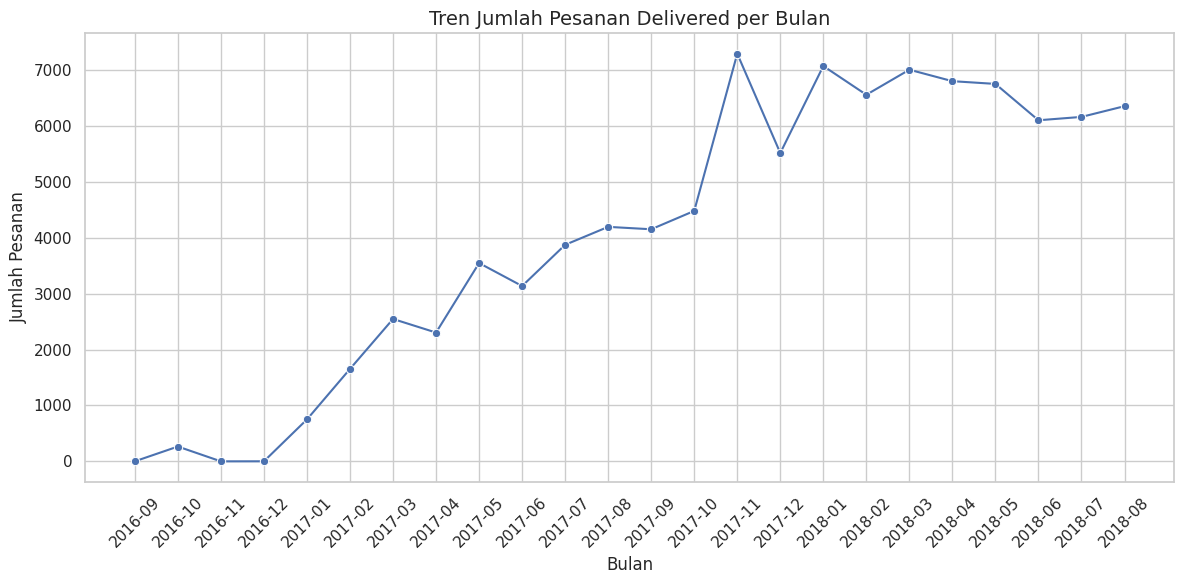

In [226]:
# Membuat visualisasi tren jumlah pesanan per bulan
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_orders_df,
    x="month",
    y="order_count",
    marker="o"
)

plt.title("Tren Jumlah Pesanan Delivered per Bulan", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Jumlah Pesanan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

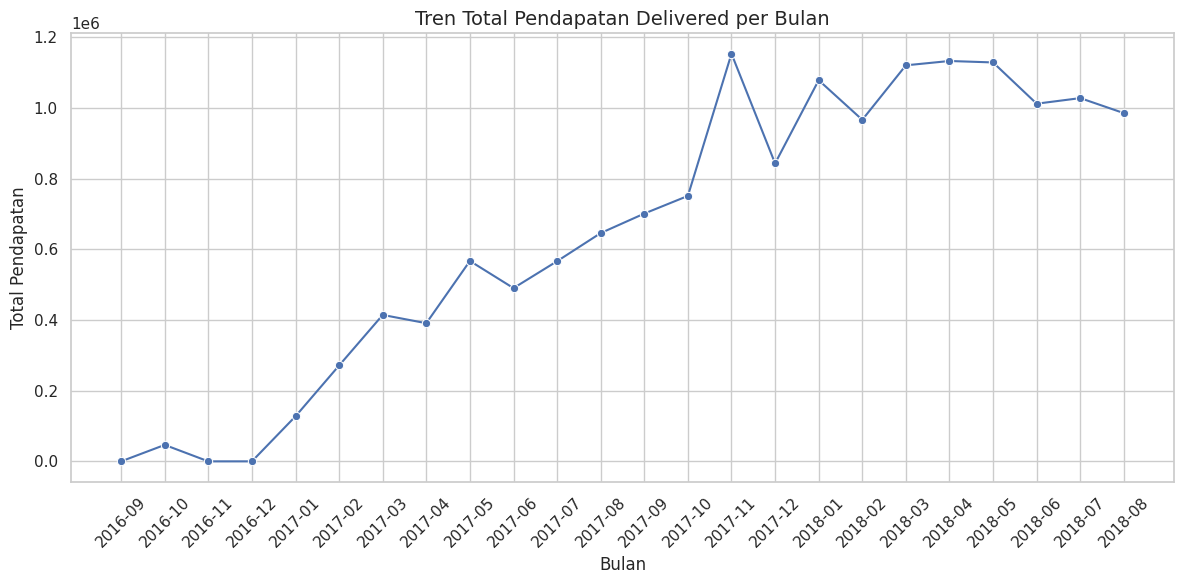

In [227]:
# Membuat visualisasi tren total pendapatan per bulan
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_orders_df,
    x="month",
    y="total_revenue",
    marker="o"
)

plt.title("Tren Total Pendapatan Delivered per Bulan", fontsize=14)
plt.xlabel("Bulan")
plt.ylabel("Total Pendapatan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi tren bulanan, jumlah pesanan dan total pendapatan mengalami perubahan dari bulan ke bulan. Visualisasi ini membantu melihat periode dengan performa penjualan yang lebih tinggi maupun lebih rendah dari pesanan yang berhasil dikirim.

### Pertanyaan 2: Kategori produk apa yang menghasilkan total pendapatan tertinggi dan terendah dari pesanan berstatus delivered selama periode 2016–2018?

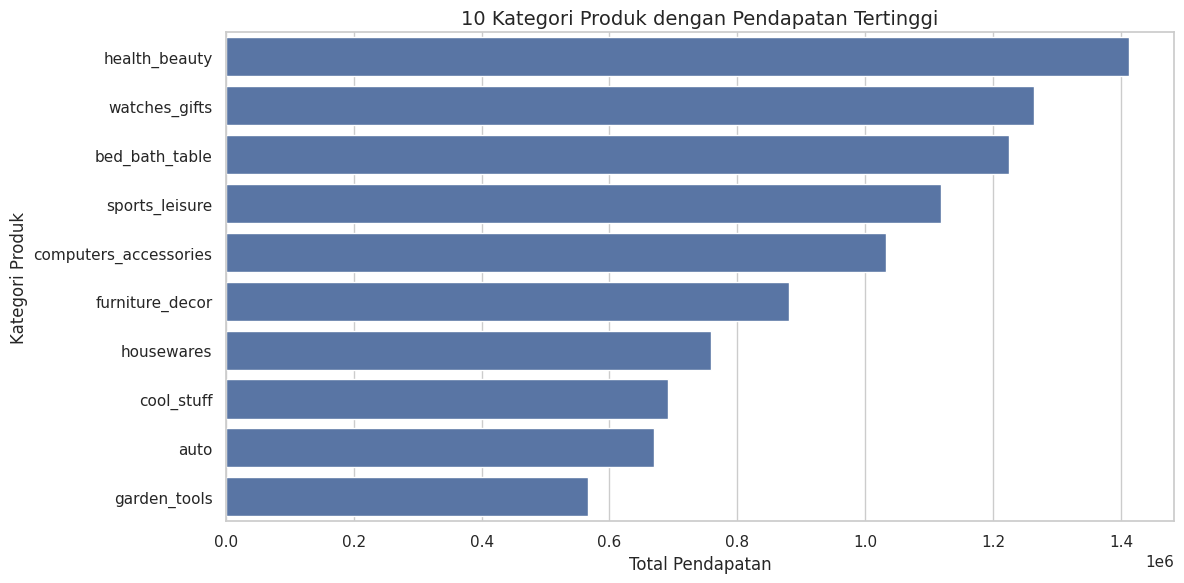

In [228]:
# Mengambil 10 kategori produk dengan pendapatan tertinggi
top_category_df = category_revenue_df.head(10)

# Membuat visualisasi kategori produk dengan pendapatan tertinggi
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_category_df,
    x="total_revenue",
    y="product_category"
)

plt.title("10 Kategori Produk dengan Pendapatan Tertinggi", fontsize=14)
plt.xlabel("Total Pendapatan")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

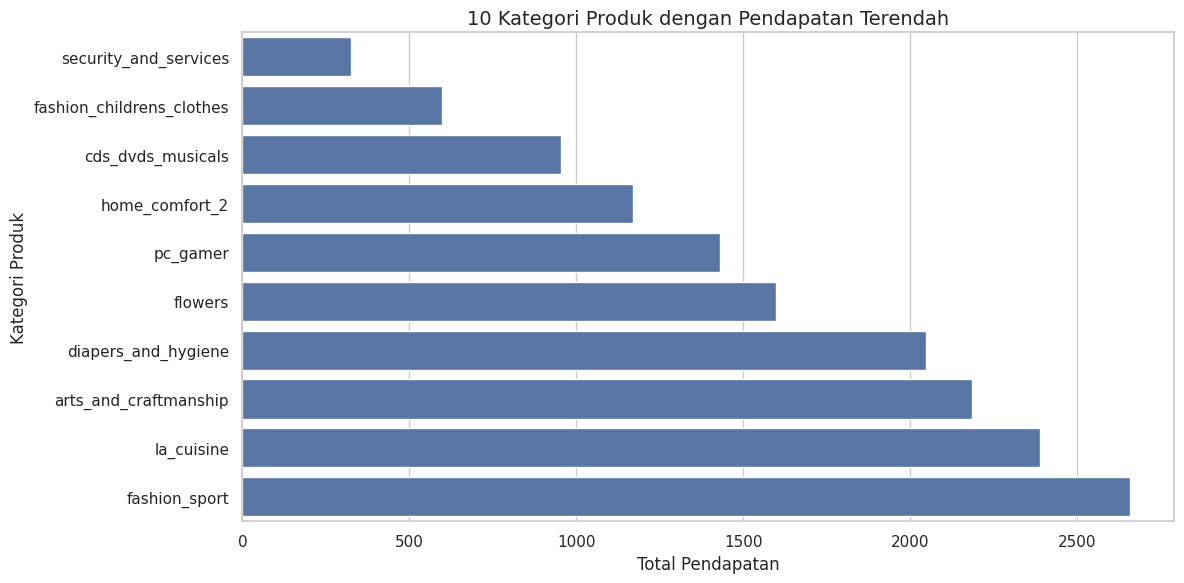

In [229]:
# Mengambil 10 kategori produk dengan pendapatan terendah
bottom_category_df = category_revenue_df.tail(10).sort_values(
    by="total_revenue",
    ascending=True
)

# Membuat visualisasi kategori produk dengan pendapatan terendah
plt.figure(figsize=(12, 6))

sns.barplot(
    data=bottom_category_df,
    x="total_revenue",
    y="product_category"
)

plt.title("10 Kategori Produk dengan Pendapatan Terendah", fontsize=14)
plt.xlabel("Total Pendapatan")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()

Berdasarkan visualisasi kategori produk, terlihat bahwa kontribusi pendapatan antar kategori tidak merata. Beberapa kategori produk menghasilkan pendapatan yang jauh lebih besar dibandingkan kategori lainnya, sedangkan beberapa kategori memiliki pendapatan yang relatif rendah.

### Pertanyaan 3: Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary dari pesanan berstatus delivered, serta segmen pelanggan mana yang perlu diprioritaskan untuk strategi retensi?

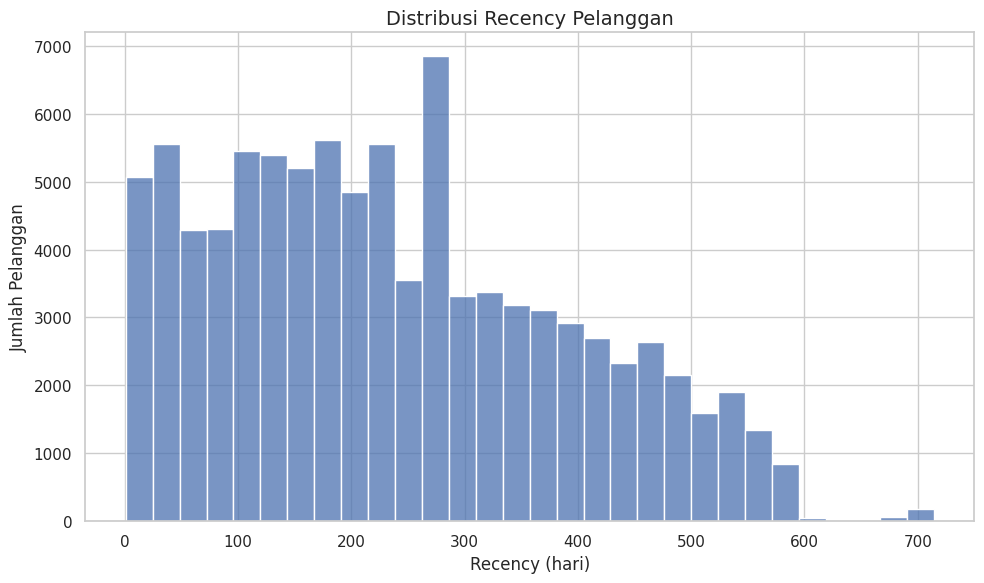

In [230]:
# Membuat visualisasi distribusi recency pelanggan
plt.figure(figsize=(10, 6))

sns.histplot(
    data=rfm_df,
    x="recency",
    bins=30
)

plt.title("Distribusi Recency Pelanggan", fontsize=14)
plt.xlabel("Recency (hari)")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

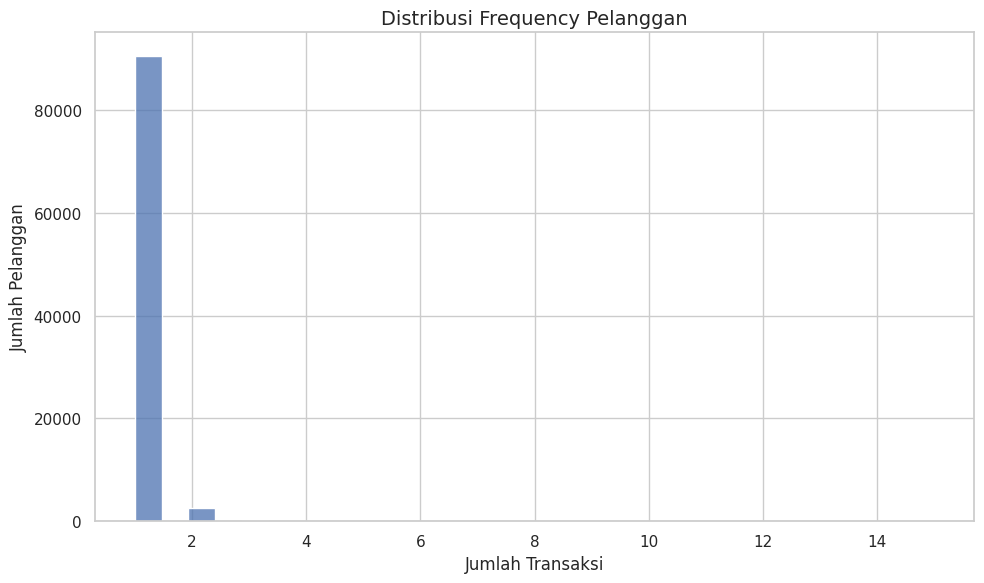

In [231]:
# Membuat visualisasi distribusi frequency pelanggan
plt.figure(figsize=(10, 6))

sns.histplot(
    data=rfm_df,
    x="frequency",
    bins=30
)

plt.title("Distribusi Frequency Pelanggan", fontsize=14)
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

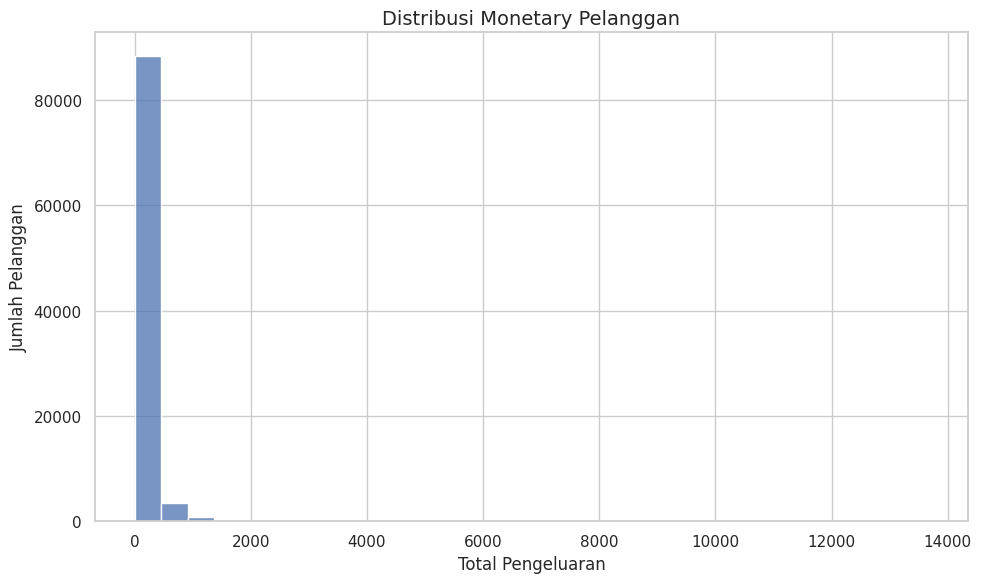

In [232]:
# Membuat visualisasi distribusi monetary pelanggan
plt.figure(figsize=(10, 6))

sns.histplot(
    data=rfm_df,
    x="monetary",
    bins=30
)

plt.title("Distribusi Monetary Pelanggan", fontsize=14)
plt.xlabel("Total Pengeluaran")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

Berdasarkan visualisasi RFM, pelanggan memiliki pola yang berbeda dari sisi waktu terakhir melakukan pembelian, jumlah transaksi, dan total pengeluaran. Perbedaan ini dapat digunakan untuk membentuk segmentasi pelanggan yang lebih sesuai dengan perilaku pembelian mereka.

**Insight:**

- Jumlah pesanan dan total pendapatan menunjukkan pola yang berubah dari bulan ke bulan, sehingga analisis tren waktu dapat membantu melihat periode dengan performa penjualan yang lebih tinggi maupun lebih rendah.
- Kategori produk dengan pendapatan tertinggi dapat menjadi prioritas dalam strategi penjualan karena memberikan kontribusi besar terhadap revenue.
- Kategori produk dengan pendapatan terendah perlu dianalisis lebih lanjut untuk mengetahui apakah rendahnya pendapatan disebabkan oleh sedikitnya transaksi, harga produk yang rendah, atau rendahnya minat pelanggan.
- Distribusi RFM menunjukkan bahwa pelanggan memiliki karakteristik pembelian yang berbeda, sehingga segmentasi pelanggan perlu dilakukan untuk mendukung strategi retensi.

## Analisis Lanjutan: RFM Analysis

Pada tahap ini, saya menggunakan RFM Analysis untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka. RFM terdiri dari tiga komponen utama, yaitu:

- Recency: jarak waktu sejak terakhir kali pelanggan melakukan pembelian.
- Frequency: jumlah transaksi yang dilakukan pelanggan.
- Monetary: total nilai pembayaran yang dilakukan pelanggan.

Analisis ini digunakan untuk membantu mengidentifikasi kelompok pelanggan bernilai tinggi, pelanggan potensial, serta pelanggan yang perlu diprioritaskan dalam strategi retensi.

In [233]:
# Membuat salinan dataframe RFM agar data awal tetap aman
rfm_analysis_df = rfm_df.copy()

# Memberikan skor recency
# Semakin kecil recency, semakin baik skornya
rfm_analysis_df["r_score"] = pd.qcut(
    rfm_analysis_df["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
)

# Memberikan skor frequency
# Semakin besar frequency, semakin baik skornya
rfm_analysis_df["f_score"] = pd.qcut(
    rfm_analysis_df["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

# Memberikan skor monetary
# Semakin besar monetary, semakin baik skornya
rfm_analysis_df["m_score"] = pd.qcut(
    rfm_analysis_df["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

# Menggabungkan skor RFM
rfm_analysis_df["rfm_score"] = (
    rfm_analysis_df["r_score"].astype(str)
    + rfm_analysis_df["f_score"].astype(str)
    + rfm_analysis_df["m_score"].astype(str)
)

rfm_analysis_df.head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [234]:
# Menghitung total skor RFM
rfm_analysis_df["total_score"] = (
    rfm_analysis_df["r_score"].astype(int)
    + rfm_analysis_df["f_score"].astype(int)
    + rfm_analysis_df["m_score"].astype(int)
)

# Membuat fungsi segmentasi pelanggan berdasarkan total skor RFM
def customer_segment(score):
    if score >= 10:
        return "High Value Customer"
    elif score >= 7:
        return "Potential Customer"
    elif score >= 4:
        return "Need Attention"
    else:
        return "At Risk Customer"

# Menerapkan fungsi segmentasi ke dataframe
rfm_analysis_df["customer_segment"] = rfm_analysis_df["total_score"].apply(customer_segment)

rfm_analysis_df.head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,total_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413,8,Potential Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311,5,Need Attention
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Need Attention
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Need Attention
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,Potential Customer


In [235]:
# Menghitung jumlah pelanggan dan rata-rata metrik RFM pada setiap segmen
segment_count_df = rfm_analysis_df.groupby("customer_segment").agg({
    "customer_unique_id": "nunique",
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean"
}).reset_index()

segment_count_df.rename(columns={
    "customer_unique_id": "customer_count",
    "recency": "avg_recency",
    "frequency": "avg_frequency",
    "monetary": "avg_monetary"
}, inplace=True)

segment_count_df

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary
0,At Risk Customer,1519,455.072416,1.000000,43.894812
1,High Value Customer,15197,114.712312,1.140620,292.226570
2,Need Attention,28070,330.907232,1.000641,88.949466
3,Potential Customer,48572,215.981718,1.019867,173.309867


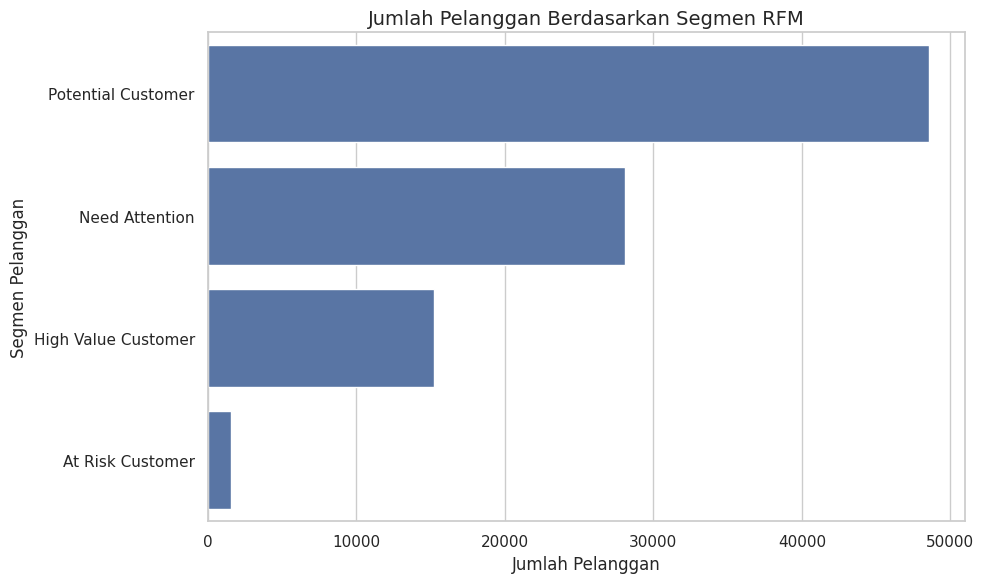

In [236]:
# Membuat visualisasi jumlah pelanggan berdasarkan segmen RFM
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_count_df.sort_values(by="customer_count", ascending=False),
    x="customer_count",
    y="customer_segment"
)

plt.title("Jumlah Pelanggan Berdasarkan Segmen RFM", fontsize=14)
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen Pelanggan")
plt.tight_layout()
plt.show()

**Insight:**

- Pelanggan berhasil dikelompokkan ke dalam beberapa segmen berdasarkan nilai Recency, Frequency, dan Monetary.
- Segmen `High Value Customer` berisi pelanggan dengan perilaku pembelian yang relatif lebih baik, yaitu memiliki skor RFM tinggi.
- Segmen `Potential Customer` dapat menjadi target untuk strategi peningkatan loyalitas pelanggan.
- Segmen `Need Attention` dan `At Risk Customer` perlu diperhatikan karena pelanggan pada kelompok ini memiliki potensi penurunan aktivitas transaksi.

Berdasarkan hasil RFM Analysis, perusahaan dapat memprioritaskan strategi pemasaran yang berbeda untuk setiap segmen pelanggan. Pelanggan bernilai tinggi dapat diberikan program loyalitas atau penawaran eksklusif, sedangkan pelanggan yang berisiko menurun aktivitasnya dapat diberikan promo khusus atau kampanye retensi.

## Ringkasan Hasil Analisis

Pada bagian ini, menampilkan beberapa hasil utama dari analisis yang telah dilakukan. Hasil ini digunakan untuk membantu menyusun kesimpulan akhir berdasarkan data.

In [237]:
# Bulan dengan jumlah pesanan tertinggi
monthly_orders_df.sort_values(by="order_count", ascending=False).head(1)

,month,order_count,total_revenue
14,2017-11,7289,1153528.05


In [238]:
# Bulan dengan total pendapatan tertinggi
monthly_orders_df.sort_values(by="total_revenue", ascending=False).head(1)

,month,order_count,total_revenue
14,2017-11,7289,1153528.05


In [239]:
# Kategori produk dengan pendapatan tertinggi
category_revenue_df.head(1)

,product_category,total_revenue,order_count
43,health_beauty,1412089.53,8647


In [240]:
# Kategori produk dengan pendapatan terendah
category_revenue_df.tail(1)

,product_category,total_revenue,order_count
63,security_and_services,324.51,2


In [241]:
# Segmen pelanggan dengan jumlah pelanggan terbanyak
segment_count_df.sort_values(by="customer_count", ascending=False).head(1)

,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary
3,Potential Customer,48572,215.981718,1.019867,173.309867


## Export Data untuk Dashboard

Pada tahap ini, beberapa dataframe hasil analisis disimpan ke dalam file CSV agar dapat digunakan pada dashboard Streamlit. Data utama yang digunakan untuk dashboard dibuat pada level item pesanan agar visualisasi tren, kategori produk, dan segmentasi pelanggan dapat berubah secara interaktif mengikuti filter tanggal.

In [242]:
# Membuat folder dashboard jika belum tersedia
import os

os.makedirs("dashboard", exist_ok=True)

In [243]:
# Membuat data utama dashboard dengan kolom yang benar-benar dibutuhkan
dashboard_main_df = item_level_df[
    [
        "order_id",
        "order_purchase_timestamp",
        "product_category",
        "revenue",
        "customer_unique_id",
        "customer_state",
        "payment_value"
    ]
].copy()

# Memastikan kategori produk tidak kosong
dashboard_main_df["product_category"] = dashboard_main_df["product_category"].fillna("unknown")

# Menampilkan sampel data utama dashboard
dashboard_main_df.head()

,order_id,order_purchase_timestamp,product_category,revenue,customer_unique_id,customer_state,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,housewares,38.71,7c396fd4830fd04220f754e42b4e5bff,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,perfumery,141.46,af07308b275d755c9edb36a90c618231,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,auto,179.12,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,pet_shop,72.20,7c142cf63193a1473d2e66489a9ae977,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,stationery,28.62,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62


In [244]:
# Menyimpan data utama untuk dashboard interaktif
dashboard_main_df.to_csv("dashboard/main_data.csv", index=False)

# Menyimpan data tren bulanan
monthly_orders_df.to_csv("dashboard/monthly_orders.csv", index=False)

# Menyimpan data kategori produk
category_revenue_df.to_csv("dashboard/category_revenue.csv", index=False)

# Menyimpan data RFM
rfm_analysis_df.to_csv("dashboard/rfm_data.csv", index=False)

# Menyimpan data jumlah pelanggan per segmen
segment_count_df.to_csv("dashboard/segment_count.csv", index=False)

## Conclusion & Recommendation



- **Conclusion pertanyaan 1:** Berdasarkan analisis tren bulanan pada pesanan berstatus delivered selama periode 2016–2018, jumlah pesanan dan total pendapatan mengalami perubahan dari bulan ke bulan. Performa tertinggi terjadi pada bulan **November 2017**, dengan jumlah pesanan dan total pendapatan yang lebih tinggi dibandingkan periode lainnya. Hal ini menunjukkan bahwa pemantauan tren bulanan penting dilakukan untuk mengidentifikasi periode dengan performa penjualan terbaik.

- **Conclusion pertanyaan 2:** Berdasarkan analisis kategori produk, terdapat perbedaan kontribusi pendapatan yang cukup besar antar kategori. Kategori **health_beauty** menjadi kategori dengan total pendapatan tertinggi, sedangkan kategori **security_and_services** menjadi kategori dengan total pendapatan terendah. Hal ini menunjukkan bahwa strategi pengelolaan kategori produk perlu disesuaikan berdasarkan kontribusi pendapatan masing-masing kategori.

- **Conclusion pertanyaan 3:** Berdasarkan RFM Analysis, pelanggan dapat dikelompokkan ke dalam beberapa segmen berdasarkan recency, frequency, dan monetary. Segmen **Potential Customer** menjadi segmen dengan jumlah pelanggan terbanyak, sehingga segmen ini perlu diprioritaskan untuk strategi retensi dan peningkatan loyalitas agar dapat berkembang menjadi pelanggan bernilai tinggi.



### Rekomendasi Action Item:

- Perusahaan dapat memanfaatkan periode dengan performa tinggi, seperti bulan November, untuk menjalankan kampanye penjualan, promosi musiman, atau strategi peningkatan transaksi.
- Kategori **health_beauty** dapat dijadikan prioritas dalam strategi pemasaran, pengelolaan stok, dan penawaran khusus karena memberikan kontribusi pendapatan terbesar.
- Kategori dengan pendapatan rendah, seperti **security_and_services**, perlu dievaluasi lebih lanjut untuk mengetahui apakah rendahnya pendapatan disebabkan oleh sedikitnya transaksi, rendahnya permintaan, atau kurangnya promosi.
- Pelanggan pada segmen **Potential Customer** dapat diberikan program loyalitas, rekomendasi produk, voucher, atau promo khusus agar dapat berkembang menjadi pelanggan bernilai tinggi.
- Pelanggan yang masuk ke segmen berisiko atau membutuhkan perhatian dapat ditargetkan dengan kampanye retensi, seperti promo personal, pengingat belanja, atau diskon khusus.

**Insight:**

- Data utama dashboard berhasil dibuat dari data level item pesanan yang sudah digabungkan dengan informasi pelanggan dan pembayaran.
- Data `main_data.csv` memuat informasi tanggal pesanan, kategori produk, nilai revenue, customer, dan payment value sehingga dapat digunakan untuk membuat dashboard yang lebih interaktif.
- File CSV hasil export akan digunakan oleh Streamlit untuk membuat visualisasi tren pesanan, pendapatan, kategori produk, dan segmentasi pelanggan yang dapat berubah berdasarkan filter tanggal.